In [11]:
soils = {
    "sand": {
        "theta_r": 0.045,
        "theta_s": 0.43,
        "alpha": 0.145,
        "vg_n": 2.68,
        "Ks": 29.7,
    },
    "loamy_sand": {
        "theta_r": 0.057,
        "theta_s": 0.41,
        "alpha": 0.124,
        "vg_n": 2.28,
        "Ks": 14.6,
    },
    "sandy_loam": {
        "theta_r": 0.065,
        "theta_s": 0.41,
        "alpha": 0.075,
        "vg_n": 1.89,
        "Ks": 4.42,
    },
    "loam": {
        "theta_r": 0.078,
        "theta_s": 0.43,
        "alpha": 0.036,
        "vg_n": 1.56,
        "Ks": 1.04,
    },
    "silt": {
        "theta_r": 0.085,
        "theta_s": 0.45,
        "alpha": 0.025,
        "vg_n": 1.35,
        "Ks": 0.52,
    }       
}


In [12]:
import numpy as np
import matplotlib.pyplot as plt

def vg_m(vg_n):
    """
    van Genuchten m parameter.
    """
    return 1 - (1 / vg_n)


def kr_van_genuchten_mualem(Se, vg_n, l=0.5):
    """
    van Genuchten-Mualem relative hydraulic conductivity.

    Se : effective saturation, between 0 and 1
    vg_n : van Genuchten n
    l : pore-connectivity/tortuosity parameter, commonly 0.5
    """
    Se = np.asarray(Se, dtype=float)
    Se = np.clip(Se, 1e-8, 1.0)

    m = vg_m(vg_n)

    Kr = Se**l * (1 - (1 - Se**(1 / m))**m)**2

    return Kr


def kr_sisson_brooks_corey(Se, n_sisson):
    """
    Sisson/Brooks-Corey relative hydraulic conductivity.
    From K = Ks * Se^(1/n_sisson).
    """
    Se = np.asarray(Se, dtype=float)
    Se = np.clip(Se, 1e-8, 1.0)

    Kr = Se ** (1 / n_sisson)

    return Kr

In [13]:
def n_sisson_option_inverse(vg_n):
    """
    Option 1: n_sisson = 1 / (vg_n - 1)
    """
    return 1 / (vg_n - 1)


def n_sisson_option_direct(vg_n):
    """
    Option 2: n_sisson = vg_n
    """
    return vg_n


def n_sisson_option_m(vg_n):
    """
    Option 3: n_sisson = m_vG = (vg_n - 1) / vg_n
    """
    return (vg_n - 1) / vg_n

In [14]:
def fit_n_sisson_to_vg_mualem(vg_n, Se_min=0.1, Se_max=0.95, l=0.5):
    """
    Fit the Sisson/Brooks-Corey exponent n_sisson so that
    Kr = Se^(1/n_sisson) approximates the van Genuchten-Mualem curve.
    """

    Se = np.linspace(Se_min, Se_max, 300)
    Kr_vg = kr_van_genuchten_mualem(Se, vg_n=vg_n, l=l)

    # Avoid log of zero
    valid = (Kr_vg > 0) & (Se > 0)

    x = np.log(Se[valid])
    y = np.log(Kr_vg[valid])

    # Force fit through origin because log(Kr) = slope * log(Se)
    slope = np.sum(x * y) / np.sum(x * x)

    n_fit = 1 / slope

    return n_fit

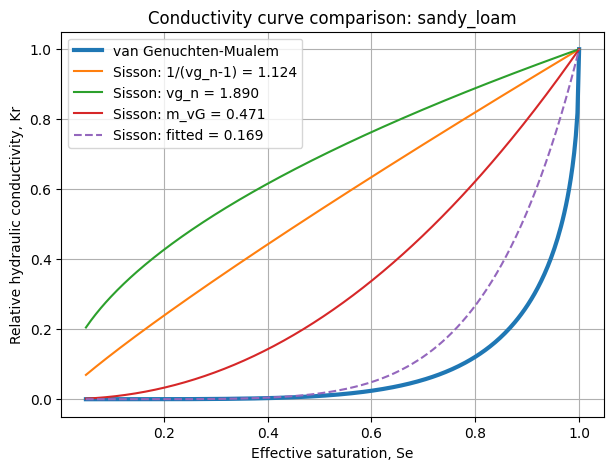

soil: sandy_loam
vg_n: 1.89
m_vG: 0.4708994708994709
n_sisson inverse: 1.1235955056179776
n_sisson direct: 1.89
n_sisson fitted: 0.16926728296047303


In [15]:
soil_name = "sandy_loam"
soil = soils[soil_name]

vg_n_value = soil["vg_n"]

Se = np.linspace(0.05, 1.0, 300)

Kr_vg = kr_van_genuchten_mualem(Se, vg_n=vg_n_value, l=0.5)

n_inverse = n_sisson_option_inverse(vg_n_value)
n_direct = n_sisson_option_direct(vg_n_value)
n_m = n_sisson_option_m(vg_n_value)
n_fit = fit_n_sisson_to_vg_mualem(vg_n_value, Se_min=0.1, Se_max=0.95, l=0.5)

plt.figure(figsize=(7, 5))

plt.plot(Se, Kr_vg, label="van Genuchten-Mualem", linewidth=3)
plt.plot(Se, kr_sisson_brooks_corey(Se, n_inverse), label=f"Sisson: 1/(vg_n-1) = {n_inverse:.3f}")
plt.plot(Se, kr_sisson_brooks_corey(Se, n_direct), label=f"Sisson: vg_n = {n_direct:.3f}")
plt.plot(Se, kr_sisson_brooks_corey(Se, n_m), label=f"Sisson: m_vG = {n_m:.3f}")
plt.plot(Se, kr_sisson_brooks_corey(Se, n_fit), label=f"Sisson: fitted = {n_fit:.3f}", linestyle="--")

plt.xlabel("Effective saturation, Se")
plt.ylabel("Relative hydraulic conductivity, Kr")
plt.title(f"Conductivity curve comparison: {soil_name}")
plt.legend()
plt.grid(True)
plt.show()

print("soil:", soil_name)
print("vg_n:", vg_n_value)
print("m_vG:", n_m)
print("n_sisson inverse:", n_inverse)
print("n_sisson direct:", n_direct)
print("n_sisson fitted:", n_fit)

In [16]:
results = []

for soil_name, soil in soils.items():
    vg_n_value = soil["vg_n"]

    n_inverse = n_sisson_option_inverse(vg_n_value)
    n_direct = n_sisson_option_direct(vg_n_value)
    n_m = n_sisson_option_m(vg_n_value)
    n_fit = fit_n_sisson_to_vg_mualem(vg_n_value, Se_min=0.1, Se_max=0.95, l=0.5)

    results.append({
        "soil": soil_name,
        "vg_n": vg_n_value,
        "m_vG": n_m,
        "n_inverse": n_inverse,
        "n_direct": n_direct,
        "n_fitted": n_fit,
    })

import pandas as pd

df_n_compare = pd.DataFrame(results)
df_n_compare

,soil,vg_n,m_vG,n_inverse,n_direct,n_fitted
0,sand,2.68,0.626866,0.595238,2.68,0.228388
1,loamy_sand,2.28,0.561404,0.781250,2.28,0.202836
2,sandy_loam,1.89,0.470899,1.123596,1.89,0.169267
3,loam,1.56,0.358974,1.785714,1.56,0.129989
4,silt,1.35,0.259259,2.857143,1.35,0.096237


In [17]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))


def log_rmse(y_true, y_pred):
    eps = 1e-12
    return np.sqrt(np.mean((np.log(y_true + eps) - np.log(y_pred + eps))**2))


soil_name = "sandy_loam"
soil = soils[soil_name]
vg_n_value = soil["vg_n"]

Se = np.linspace(0.05, 1.0, 300)

Kr_vg = kr_van_genuchten_mualem(Se, vg_n=vg_n_value, l=0.5)

options = {
    "1/(vg_n - 1)": n_sisson_option_inverse(vg_n_value),
    "vg_n": n_sisson_option_direct(vg_n_value),
    "m_vG": n_sisson_option_m(vg_n_value),
    "fitted": fit_n_sisson_to_vg_mualem(vg_n_value, Se_min=0.1, Se_max=0.95, l=0.5),
}

for label, n_sisson in options.items():
    Kr_sisson = kr_sisson_brooks_corey(Se, n_sisson)

    print(label)
    print("n_sisson:", n_sisson)
    print("RMSE:", rmse(Kr_vg, Kr_sisson))
    print("log RMSE:", log_rmse(Kr_vg, Kr_sisson))
    print()

1/(vg_n - 1)
n_sisson: 1.1235955056179776
RMSE: 0.5080256593264789
log RMSE: 5.395931138021392

vg_n
n_sisson: 1.89
RMSE: 0.6189477567538297
log RMSE: 5.792237401685951

m_vG
n_sisson: 0.4708994708994709
RMSE: 0.3143209753847093
log RMSE: 4.045568938089211

fitted
n_sisson: 0.16926728296047303
RMSE: 0.12179662163208209
log RMSE: 0.6967682504348729



In [18]:
summary = []

for soil_name, soil in soils.items():
    vg_n_value = soil["vg_n"]
    Se = np.linspace(0.05, 1.0, 300)
    Kr_vg = kr_van_genuchten_mualem(Se, vg_n=vg_n_value, l=0.5)

    n_options = {
        "inverse": n_sisson_option_inverse(vg_n_value),
        "direct": n_sisson_option_direct(vg_n_value),
        "m_vG": n_sisson_option_m(vg_n_value),
        "fitted": fit_n_sisson_to_vg_mualem(vg_n_value, Se_min=0.1, Se_max=0.95, l=0.5),
    }

    row = {
        "soil": soil_name,
        "vg_n": vg_n_value,
        "m_vG": n_options["m_vG"],
        "n_fitted": n_options["fitted"],
    }

    for label, n_sisson in n_options.items():
        Kr_sisson = kr_sisson_brooks_corey(Se, n_sisson)
        row[f"{label}_RMSE"] = rmse(Kr_vg, Kr_sisson)
        row[f"{label}_log_RMSE"] = log_rmse(Kr_vg, Kr_sisson)

    summary.append(row)

df_compare = pd.DataFrame(summary)
df_compare

,soil,vg_n,m_vG,n_fitted,inverse_RMSE,inverse_log_RMSE,direct_RMSE,direct_log_RMSE,m_vG_RMSE,m_vG_log_RMSE,fitted_RMSE,fitted_log_RMSE
0,sand,2.68,0.626866,0.228388,0.286943,2.895477,0.626329,4.333513,0.299252,2.988529,0.081861,0.375349
1,loamy_sand,2.28,0.561404,0.202836,0.383910,3.922566,0.621261,4.847747,0.307062,3.372834,0.098842,0.492541
2,sandy_loam,1.89,0.470899,0.169267,0.508026,5.395931,0.618948,5.792237,0.314321,4.045569,0.121797,0.696768
3,loam,1.56,0.358974,0.129989,0.646944,7.675911,0.619989,7.587076,0.313919,5.245364,0.146164,1.044487
4,silt,1.35,0.259259,0.096237,0.758043,10.808569,0.620248,10.380496,0.298691,6.984466,0.158626,1.414459
